In [1]:
!pip install lunardate

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from lunardate import LunarDate
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

from lightgbm import LGBMRegressor
from tqdm import tqdm

import matplotlib.pyplot as plt #visual
import seaborn as sns #visual

/kaggle/input/competitions/hbaac-round2/sample_submission.csv
/kaggle/input/competitions/hbaac-round2/train.csv


In [3]:
# 1. LOAD VÀ XEM DATA

sample = pd.read_csv("/kaggle/input/competitions/hbaac-round2/sample_submission.csv")
train_raw = pd.read_csv("/kaggle/input/competitions/hbaac-round2/train.csv")

print("file sample")
display(sample)

train = train_raw
print("file train")
display(train)

/tmp/ipykernel_16/1600751180.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train_raw = pd.read_csv("/kaggle/input/competitions/hbaac-round2/train.csv")


file sample


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,SKU-00002_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,SKU-00003_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,SKU-00004_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,SKU-00005_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31939,SKU-16329_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31940,SKU-16330_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31941,SKU-16331_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31942,SKU-16332_evaluation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


file train


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000
...,...,...,...,...,...,...,...,...
711975,2025-09-05,1933614,SKU-11617,1,468000,468000,365924,365924
711976,2025-09-05,1933616,SKU-09360,1,470000,470000,"312747,5",312747
711977,2025-09-05,1933616,SKU-09433,2,960000,1920000,"768779,63",1537559
711978,2025-09-05,1933616,SKU-11885,2,150000,300000,"114074,07",228148


,Kiểu dữ liệu,Giá trị duy nhất,Số lượng trống,Tỷ lệ (%)
Date,object,1411,0,0.0
Stt,object,327283,0,0.0
ItemCode,object,15972,0,0.0
Quantity,int64,360,0,0.0
UnitPrice,object,24114,0,0.0
SalesAmount,int64,52820,0,0.0
Unit Cost,object,149008,0,0.0
Cost Amount,object,182660,0,0.0


,Quantity
count,711980.000000
mean,3.437250
std,25.490722
min,-998.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,5998.000000


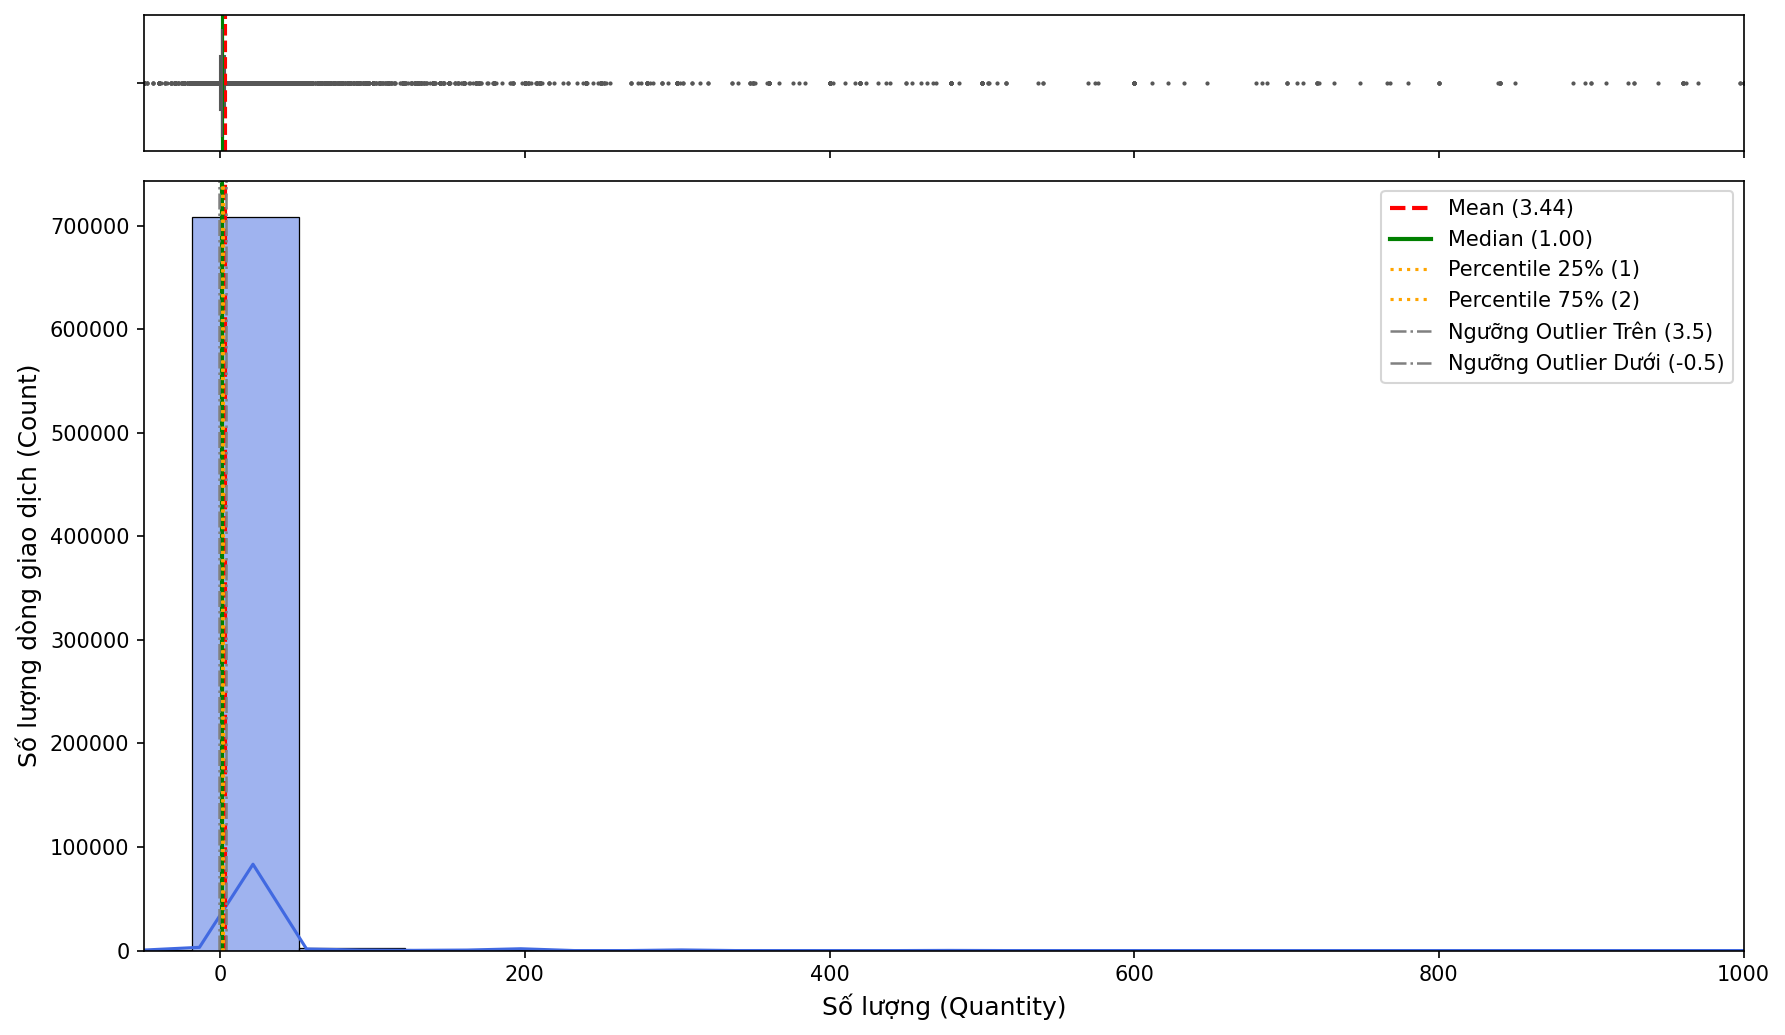

In [4]:
# 2. KHAI PHÁ DỮ LIỆU

# ---------------------------------------------------------------------------------
# 2.1. ???
def check_data(df):
    info_df = pd.DataFrame({
        'Kiểu dữ liệu': df.dtypes.astype(str),
        'Giá trị duy nhất': df.nunique(),
        'Số lượng trống': df.isnull().sum(),
        'Tỷ lệ (%)': (df.isnull().mean() * 100).round(2)
    })
    return info_df
display(check_data(train_raw))
# ---------------------------------------------------------------------------------
# 2.2. Mô tả biến mục tiêu
display(train[["Quantity"]].describe())
# ---------------------------------------------------------------------------------
# 2.3 Visual biến mục tiêu

# Tính toán các chỉ số thống kê cơ bản
mean_qty = train['Quantity'].mean()
median_qty = train['Quantity'].median()
q25 = train['Quantity'].quantile(0.25)
q75 = train['Quantity'].quantile(0.75)
iqr = q75 - q25

# Xác định ngưỡng Outlier lý thuyết theo công thức Tukey Boxplot
lower_bound = q25 - 1.5 * iqr
upper_bound = q75 + 1.5 * iqr

# Tạo khung hình gồm 2 hàng (Boxplot trên, Hist dưới)
f, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, dpi=150)

# Vẽ Boxplot
sns.boxplot(x=train['Quantity'], color='royalblue', fliersize=1, ax=ax_box)
ax_box.axvline(mean_qty, color='red', linestyle='--', linewidth=1.5, label=f'Mean ({mean_qty:.2f})')
ax_box.axvline(median_qty, color='green', linestyle='-', linewidth=1.5, label=f'Median ({median_qty:.2f})')

# Vẽ Histogram với KDE
sns.histplot(train['Quantity'], kde=True, color='royalblue', ax=ax_hist, bins=100)
ax_hist.set(xlabel='Quantity', ylabel='Tần suất')

# Thêm các đường chỉ số vào Histogram
ax_hist.axvline(mean_qty, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_qty:.2f})')
ax_hist.axvline(median_qty, color='green', linestyle='-', linewidth=2, label=f'Median ({median_qty:.2f})')
ax_hist.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Percentile 25% ({q25:.0f})')
ax_hist.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Percentile 75% ({q75:.0f})')

# Đánh dấu vùng Outlier bằng đường nét đứt mảnh màu xám
ax_hist.axvline(upper_bound, color='gray', linestyle='-.', linewidth=1.2, label=f'Ngưỡng Outlier Trên ({upper_bound})')
ax_hist.axvline(lower_bound, color='gray', linestyle='-.', linewidth=1.2, label=f'Ngưỡng Outlier Dưới ({lower_bound})')

ax_hist.set_xlim(-50, 1000)
ax_hist.set_xlabel('Số lượng (Quantity)', fontsize=12)
ax_hist.set_ylabel('Số lượng dòng giao dịch (Count)', fontsize=12)

ax_hist.legend()
plt.tight_layout()
plt.show()

In [5]:
# =====================================================================
# 3. TIỀN XỬ LÝ & PIPELINE DỮ LIỆU CHUỖI THỜI GIAN
# =====================================================================

pd.options.display.float_format = lambda x: f"{x:,.0f}" if x == int(x) else f"{x:,.2f}"

# Ép kiểu dữ liệu ngày tháng
train["Date"] = pd.to_datetime(train["Date"])

# Chuẩn hóa định dạng dấu phẩy thập phân cho giá lẻ và giá vốn
for col in ["UnitPrice","Unit Cost"]:
    if col in train.columns and train[col].dtype == "object":
        train[col] = train[col].astype(str).str.replace(",", ".").astype(float)

# ---------------------------------------------------------------------
# train_1: Bỏ cột thừa + Aggregate theo ngày (Sửa 'first' thành 'median')
# ---------------------------------------------------------------------
train_1 = (
    train
    .drop(columns=["Stt","SalesAmount","Cost Amount"], errors="ignore")
    .groupby(["Date","ItemCode"], as_index=False)
    .agg({"Quantity":"sum", "UnitPrice":"median", "Unit Cost":"median"}) # Thay 'first' bằng 'median' để lấy giá đại diện chuẩn nhất
)

# ---------------------------------------------------------------------
# train_2: Xử lý Quantity (Âm & Outliers)
# ---------------------------------------------------------------------
train_2 = train_1.copy()

train_2["Quantity"] = train_2["Quantity"].clip(lower=0)
cap = train_2["Quantity"].quantile(0.999)
train_2["Quantity"] = train_2["Quantity"].clip(upper=cap)

# ---------------------------------------------------------------------
# train_3: Reindex tạo lưới thời gian phẳng liên tục
# ---------------------------------------------------------------------
all_dates = pd.date_range(train_2["Date"].min(), train_2["Date"].max())
all_skus = train_2["ItemCode"].unique()

train_3 = (
    train_2
    .set_index(["Date","ItemCode"])
    .reindex(pd.MultiIndex.from_product([all_dates, all_skus], names=["Date","ItemCode"]))
    .reset_index()
)

# Điền lượng bán bằng 0 cho ngày trống
train_3["Quantity"] = train_3["Quantity"].fillna(0)

# Điền bù thông tin giá cả bằng ffill và bfill theo từng SKU
for col in ["UnitPrice","Unit Cost"]:
    train_3[col] = train_3.groupby("ItemCode")[col].ffill().bfill()

# ---------------------------------------------------------------------
# train_4: Cấu trúc Đặc trưng Thời gian + Lịch âm/Dương bản địa + Lag + Rolling
# ---------------------------------------------------------------------
train_4 = train_3.copy()

# Cập nhật đặc trưng thời gian chuẩn xác dựa trên cột Date mới sau Reindex
train_4["Month"] = train_4["Date"].dt.month
train_4["DayofMonth"] = train_4["Date"].dt.day
train_4["DayofWeek"] = train_4["Date"].dt.dayofweek
train_4["Is_Weekend"] = (train_4["DayofWeek"] >= 5).astype(int)

train_4["Season"] = np.select(
    [train_4["Month"].isin([2,3,4]), train_4["Month"].isin([5,6,7]), train_4["Month"].isin([8,9,10])],
    [1,2,3],
    default=4
)

# Xử lý Ngày lễ thông qua bảng tối ưu Unique Dates
unique_dates = pd.DataFrame({"Date": train_4["Date"].unique()})

# Tối ưu hóa hàm đổi lịch âm (Chỉ gọi hàm chuyển đổi 1 lần duy nhất thay vì 2 lần)
def get_lunar_month_day(d):
    lunar = LunarDate.fromSolarDate(d.year, d.month, d.day)
    return pd.Series([lunar.month, lunar.day])

unique_dates[["L_Month","L_Day"]] = unique_dates["Date"].apply(get_lunar_month_day)

# Định nghĩa các ngày hội mua sắm Dương lịch và Lễ Tết Âm lịch Việt Nam
solar_fest = {(1,1),(2,14),(2,27),(3,8),(4,1),(4,30),(5,1),(5,13),(5,19),(6,1),(6,17),(9,2),(10,20),(10,31),(11,19),(11,20),(12,24)}
lunar_fest = {(1,1),(1,2),(1,3),(1,4),(1,5),(1,15),(3,3),(3,10),(4,15),(5,5),(7,7),(7,15),(8,15),(12,23)}

unique_dates["Is_Holiday"] = unique_dates.apply(
    lambda r: int((r["Date"].month, r["Date"].day) in solar_fest or (r["L_Month"], r["L_Day"]) in lunar_fest),
    axis=1
)

# Khớp cột Is_Holiday vào bảng tổng train_4
train_4 = train_4.merge(unique_dates[["Date","Is_Holiday"]], on="Date", how="left")

# Sắp xếp chuỗi để tạo đặc trưng tịnh tiến
train_4 = train_4.sort_values(["ItemCode","Date"]).reset_index(drop=True)
g = train_4.groupby("ItemCode")["Quantity"]

# Tạo biến Lag an toàn cho mô hình dự báo chuỗi dài 28 ngày
train_4["lag_28"] = g.shift(28)
train_4["lag_35"] = g.shift(35)
train_4["lag_56"] = g.shift(56)

# Tính toán các biến cửa sổ trượt (Rolling) dựa trên cột lag_28 sẵn có để tăng tốc độ CPU
g_lag = train_4.groupby("ItemCode")["lag_28"]
train_4["rolling_mean_7"] = g_lag.transform(lambda x: x.rolling(7).mean())
train_4["rolling_mean_28"] = g_lag.transform(lambda x: x.rolling(28).mean())
train_4["rolling_std_7"] = g_lag.transform(lambda x: x.rolling(7).std())

# Thay vì dập fillna(0) bừa bãi làm rác pha khởi động, ta xóa bỏ vùng thiếu lịch sử tịnh tiến đầu tập dữ liệu
train_4.dropna(subset=["lag_56", "rolling_mean_28"], inplace=True)
train_4.reset_index(drop=True, inplace=True)

# Hiển thị kiểm tra thành quả
display(train_4.head())
print("Kích thước ma trận dữ liệu huấn luyện cuối cùng:", train_4.shape)

,Date,ItemCode,Quantity,UnitPrice,Unit Cost,Month,DayofMonth,DayofWeek,Is_Weekend,Season,Is_Holiday,lag_28,lag_35,lag_56,rolling_mean_7,rolling_mean_28,rolling_std_7
0,2021-01-12,SKU-00001,0,"242,727.27","123,559.10",1,12,1,0,4,0,0,0,0,0,0,0
1,2021-01-13,SKU-00001,0,"242,727.27","123,559.10",1,13,2,0,4,0,0,0,0,0,0,0
2,2021-01-14,SKU-00001,0,"242,727.27","123,559.10",1,14,3,0,4,0,0,0,0,0,0,0
3,2021-01-15,SKU-00001,0,"242,727.27","123,559.10",1,15,4,0,4,0,0,0,0,0,0,0
4,2021-01-16,SKU-00001,0,"242,727.27","123,559.10",1,16,5,1,4,0,0,0,0,0,0,0


Kích thước ma trận dữ liệu huấn luyện cuối cùng: (27120456, 17)


In [6]:
# giảm RAM trước khi train

train_4["ItemCode"] = train_4["ItemCode"].astype("category")

int_cols = train_4.select_dtypes(include="int").columns
float_cols = train_4.select_dtypes(include="float").columns

train_4[int_cols] = train_4[int_cols].apply(pd.to_numeric, downcast="integer")
train_4[float_cols] = train_4[float_cols].apply(pd.to_numeric, downcast="float")

print(
    "RAM:",
    round(
        train_4.memory_usage(deep=True).sum()/1024**2,
        1
    ),
    "MB"
)

RAM: 1553.2 MB


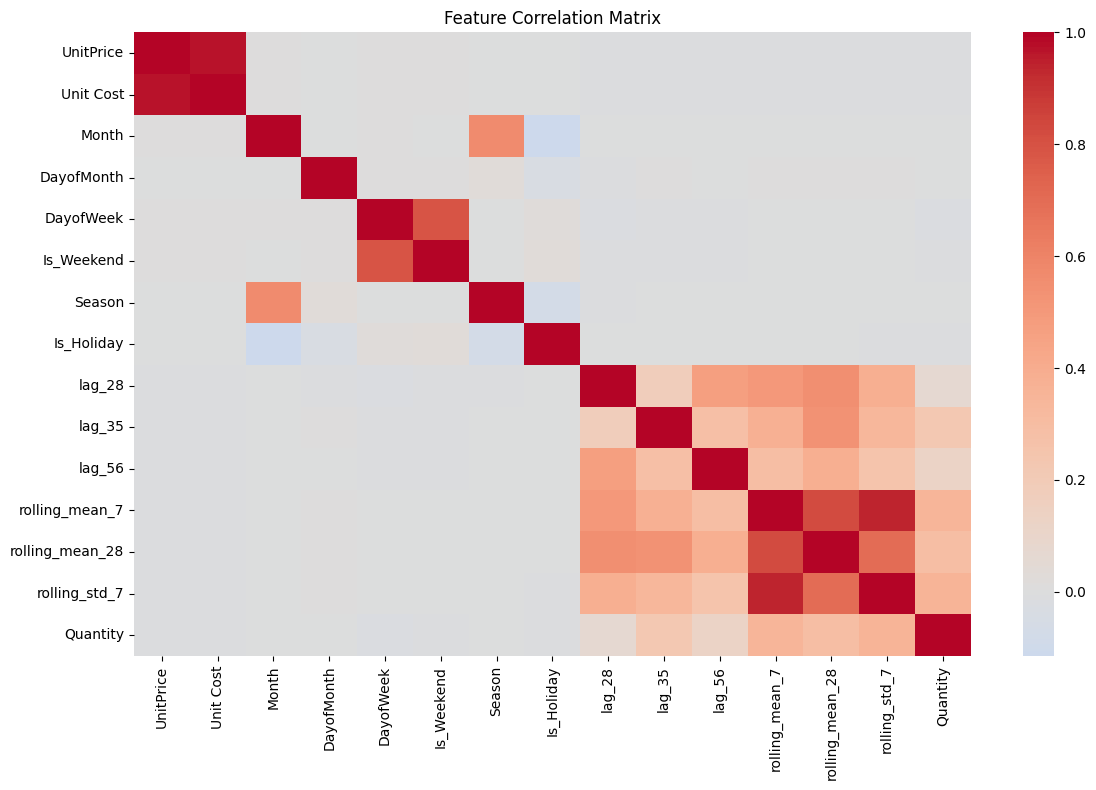

Feature tương quan cao (>0.90):
['Unit Cost', 'rolling_std_7']
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.338962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16909
[LightGBM] [Info] Number of data points in the train set: 27120456, number of used features: 15
[LightGBM] [Info] Start training from score 0.082429


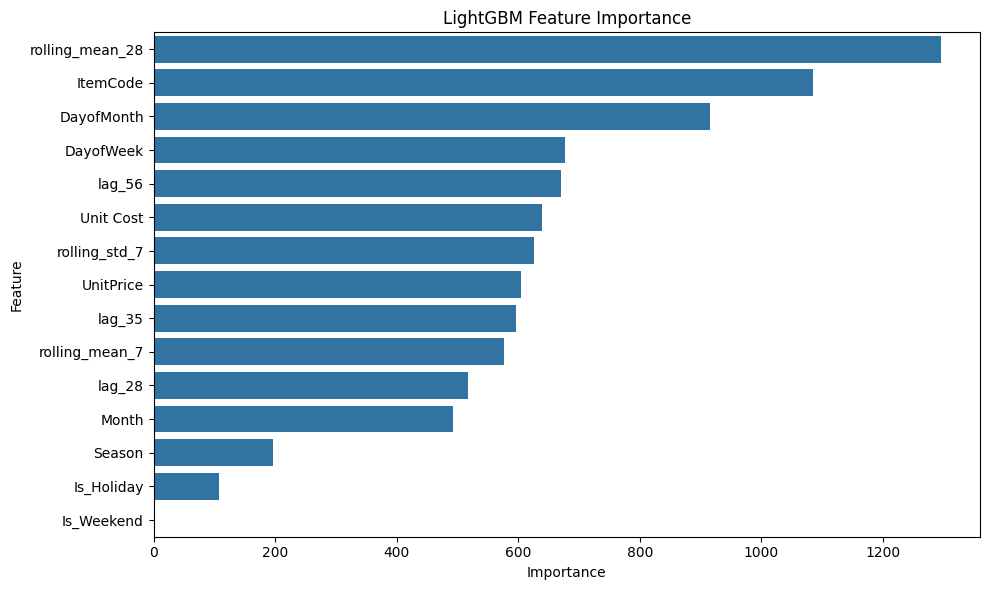


Feature importance = 0:
['Is_Weekend']

=> Không drop tự động. Chỉ review trước khi train.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb

# =====================================================================
# 5. FEATURE SELECTION
# =====================================================================

# 5.1 Chọn đúng các biến đang tồn tại
features = [
    "ItemCode","UnitPrice","Unit Cost",
    "Month","DayofMonth","DayofWeek",
    "Is_Weekend","Season","Is_Holiday",
    "lag_28","lag_35","lag_56",
    "rolling_mean_7","rolling_mean_28","rolling_std_7"
]

target = "Quantity"

# Chỉ lấy biến số để tính correlation
num_features = [
    c for c in features
    if c != "ItemCode"
]

# Lấy mẫu để giảm RAM
df_select = (
    train_4[num_features + [target]]
    .sample(
        n=min(50000, len(train_4)),
        random_state=42
    )
)

# =====================================================================
# 5.2 MA TRẬN TƯƠNG QUAN
# =====================================================================

corr = df_select.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

# =====================================================================
# 5.3 GỢI Ý FEATURE CẦN REVIEW (KHÔNG AUTO DROP)
# =====================================================================

upper = corr.abs().where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

to_review = []

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.90]

    if len(high_corr) > 0:
        to_review.append(col)

print("Feature tương quan cao (>0.90):")

if len(to_review) == 0:
    print("Không có")
else:
    print(to_review)

# =====================================================================
# 5.4 LIGHTGBM FEATURE IMPORTANCE (SƠ BỘ)
# =====================================================================

train_tmp = train_4.copy()

train_tmp["ItemCode"] = (
    train_tmp["ItemCode"]
    .astype("category")
)

X = train_tmp[features]
y = train_tmp[target]

model_fs = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

model_fs.fit(
    X,
    y,
    categorical_feature=["ItemCode"]
)

importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": model_fs.feature_importances_
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "LightGBM Feature Importance"
)

plt.tight_layout()

plt.show()

# =====================================================================
# 5.5 ĐỀ XUẤT BỎ BIẾN
# =====================================================================

low_importance = (
    importance[
        importance["Importance"] == 0
    ]["Feature"]
    .tolist()
)

print("\nFeature importance = 0:")

if len(low_importance) == 0:
    print("Không có")
else:
    print(low_importance)

print("\n=> Không drop tự động. Chỉ review trước khi train.")

In [8]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import (mean_squared_error, mean_absolute_error,r2_score)

# =====================================================================
# 6. CHỌN FEATURE CUỐI CÙNG
# =====================================================================

selected_features = (
    importance
    .query("Importance > 0")
    ["Feature"]
    .tolist()
)

if "ItemCode" not in selected_features:
    selected_features.insert(0, "ItemCode")

print("Selected features:")
print(selected_features)

# =====================================================================
# 7. TIME SPLIT
# =====================================================================

train_4["ItemCode"] = train_4["ItemCode"].astype("category")

max_date = train_4["Date"].max()

test_start = max_date - pd.Timedelta(days=27)
val_start = test_start - pd.Timedelta(days=28)

train_mask = train_4["Date"] < val_start
val_mask = (
    (train_4["Date"] >= val_start)
    &
    (train_4["Date"] < test_start)
)

test_mask = train_4["Date"] >= test_start

X_train = train_4.loc[train_mask, selected_features]
y_train = train_4.loc[train_mask, "Quantity"]

X_val = train_4.loc[val_mask, selected_features]
y_val = train_4.loc[val_mask, "Quantity"]

X_test = train_4.loc[test_mask, selected_features]
y_test = train_4.loc[test_mask, "Quantity"]

print(
    X_train.shape,
    X_val.shape,
    X_test.shape
)

# =====================================================================
# 8. TRAIN LIGHTGBM
# =====================================================================

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    categorical_feature=["ItemCode"],
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            100,
            verbose=False
        )
    ]
)

print(
    "Best iteration:",
    model.best_iteration_
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =====================================================================
# 9. TEST
# =====================================================================

y_pred = model.predict(
    X_test,
    num_iteration=model.best_iteration_
)

y_pred = np.clip(
    y_pred,
    0,
    None
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nRESULT")
print("RMSE:", round(rmse,3))
print("MAE :", round(mae,3))
print("R²  :", round(r2,4))

# =====================================================================
# 10. FEATURE IMPORTANCE
# =====================================================================

final_imp = (
    pd.DataFrame({
        "Feature": selected_features,
        "Importance": model.feature_importances_
    })
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(final_imp)

Selected features:
['rolling_mean_28', 'ItemCode', 'DayofMonth', 'DayofWeek', 'lag_56', 'Unit Cost', 'rolling_std_7', 'UnitPrice', 'lag_35', 'rolling_mean_7', 'lag_28', 'Month', 'Season', 'Is_Holiday']
(26226024, 14) (447216, 14) (447216, 14)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.095841 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16920
[LightGBM] [Info] Number of data points in the train set: 26226024, number of used features: 14
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM

,Feature,Importance
1,ItemCode,334
0,rolling_mean_28,285
2,DayofMonth,279
3,DayofWeek,260
5,Unit Cost,256
7,UnitPrice,198
11,Month,182
4,lag_56,166
9,rolling_mean_7,162
6,rolling_std_7,162


In [9]:
print((train_4["Quantity"]==0).mean())

print(final_imp)

print(
    y_test.describe()
)

0.9824367628626893
            Feature  Importance
1          ItemCode         334
0   rolling_mean_28         285
2        DayofMonth         279
3         DayofWeek         260
5         Unit Cost         256
7         UnitPrice         198
11            Month         182
4            lag_56         166
9    rolling_mean_7         162
6     rolling_std_7         162
10           lag_28         142
8            lag_35         137
12           Season          69
13       Is_Holiday          34
count   447,216
mean       0.08
std        2.01
min           0
25%           0
50%           0
75%           0
max      333.95
Name: Quantity, dtype: float64
